# Student Performance Prediction Using ANN

## Objective
Predict student performance (`final_grade`) using an Artificial Neural Network (ANN) on the Student Performance dataset.

- Target Column: `final_grade`
- Model: Artificial Neural Network (Regression)

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## 2. Load Dataset and Basic EDA

In [ ]:
df = pd.read_csv('/content/student_performance_prediction_dataset-2.csv')
df.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180282 entries, 0 to 180281
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             180282 non-null  int64  
 1   age                    180282 non-null  int64  
 2   gender                 180282 non-null  object 
 3   study_hours            180282 non-null  float64
 4   attendance             180282 non-null  float64
 5   sleep_hours            180282 non-null  float64
 6   previous_grade         180282 non-null  float64
 7   assignments_completed  180282 non-null  float64
 8   practice_tests_taken   180282 non-null  float64
 9   group_study_hours      180282 non-null  float64
 10  notes_quality_score    180282 non-null  float64
 11  time_management_score  180281 non-null  float64
 12  motivation_level       180281 non-null  float64
 13  mental_health_score    180281 non-null  float64
 14  screen_time            180281 non-nu

In [ ]:
df.describe()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
count,180282.000000,180282.000000,180282.000000,180282.000000,180282.000000,180282.000000,180282.000000,180282.000000,180282.000000,180282.000000,180281.000000,180281.000000,180281.000000,180281.000000,180281.000000,180281.000000
mean,90141.500000,18.005037,4.502074,84.701041,6.994613,69.864462,7.833506,4.013401,1.528346,6.946195,6.466487,6.944770,6.980215,4.027770,2.531320,53.069897
std,52043.074952,2.000551,1.982764,9.415823,1.462171,14.700052,1.734015,1.956306,0.941501,1.887372,1.927393,1.887590,1.471003,1.961480,1.435739,12.236080
min,1.000000,15.000000,0.000000,41.136967,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,45071.250000,16.000000,3.138886,78.235949,5.996435,59.876286,6.653207,2.649677,0.825406,5.654077,5.141844,5.655415,5.980482,2.661491,1.494205,44.822470
50%,90141.500000,18.000000,4.492855,85.014311,7.000414,69.980291,7.998599,4.000366,1.497991,7.014300,6.497074,7.004381,6.989921,4.004489,2.498871,53.142313
75%,135211.750000,20.000000,5.846847,91.722700,8.016614,80.153986,9.355259,5.342736,2.171964,8.361132,7.848708,8.355964,8.006654,5.363295,3.513331,61.383159
max,180282.000000,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000,100.000000


## 3. Handle Missing Values and Duplicates

In [ ]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        1
motivation_level             1
mental_health_score          1
screen_time                  1
social_media_hours           1
family_income                1
parent_education             1
internet_access              1
device_type               9059
school_type                  1
extracurriculars         30222
final_grade                  1
grade_category               4
pass_fail                    1
dtype: int64
Duplicates: 0


In [ ]:
df['extracurriculars'] = df['extracurriculars'].fillna('None')
df['device_type'] = df['device_type'].fillna(df['device_type'].mode()[0])

## 4. Feature Selection and Encoding

In [ ]:
# Drop rows where the target variable is missing before splitting
df = df.dropna(subset=['final_grade'])

X = df.drop(columns=['student_id', 'final_grade', 'grade_category', 'pass_fail'])
y = df['final_grade']

X = pd.get_dummies(X, drop_first=True)

## 5. Train-Test Split and Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. ANN Models Training

### Model 1: ReLU + Adam (50 Epochs)

In [ ]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model1.compile(optimizer='adam', loss='mse', metrics=['mae'])
history1 = model1.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=256)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


451/451 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 556.9621 - mae: 15.5219 - val_loss: 43.0160 - val_mae: 5.2421
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 37.8794 - mae: 4.9116 - val_loss: 34.1368 - val_mae: 4.6627
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32.2516 - mae: 4.5340 - val_loss: 30.9579 - val_mae: 4.4433
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 30.0937 - mae: 4.3787 - val_loss: 29.7719 - val_mae: 4.3565
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 29.0563 - mae: 4.3015 - val_loss: 29.0289 - val_mae: 4.2992
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28.5001 - mae: 4.2591 - val_loss: 28.5418 - val_mae: 4.2599
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 28.0602 - mae: 4.2256 - val_loss: 28.2918 - val_mae: 4.2414
Epoch 8/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 27.7788 - mae: 4.2040 - val_loss: 28.1375 - val_mae: 4.2290
Epoch 9/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/st

### Model 2: Tanh + SGD (50 Epochs)

In [ ]:
model2 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1)
])

model2.compile(optimizer='sgd', loss='mse', metrics=['mae'])
history2 = model2.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=256)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


451/451 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 49.2721 - mae: 4.7190 - val_loss: 26.3076 - val_mae: 4.0899
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26.2654 - mae: 4.0900 - val_loss: 26.0550 - val_mae: 4.0659
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25.9469 - mae: 4.0639 - val_loss: 26.1565 - val_mae: 4.0804
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25.7610 - mae: 4.0493 - val_loss: 25.8230 - val_mae: 4.0535
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 25.6130 - mae: 4.0380 - val_loss: 25.8412 - val_mae: 4.0538
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 25.5276 - mae: 4.0322 - val_loss: 26.1891 - val_mae: 4.0808
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25.4819 - mae: 4.0276 - val_loss: 25.5934 - val_mae: 4.0383
Epoch 8/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25.4009 - mae: 4.0222 - val_loss: 25.5801 - val_mae: 4.0326
Epoch 9/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

### Model 3: Sigmoid + RMSprop (50 Epochs)

In [ ]:
model3 = Sequential([
    Dense(64, activation='sigmoid', input_shape=(X_train.shape[1],)),
    Dense(32, activation='sigmoid'),
    Dense(1)
])

model3.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history3 = model3.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=256)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


451/451 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2130.0435 - mae: 44.3431 - val_loss: 1580.0714 - val_mae: 37.8463
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1095.4480 - mae: 30.5015 - val_loss: 651.2020 - val_mae: 22.7534
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 399.0682 - mae: 16.7641 - val_loss: 209.6707 - val_mae: 11.6759
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 114.6734 - mae: 8.1319 - val_loss: 51.5646 - val_mae: 5.4162
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 38.3167 - mae: 4.7756 - val_loss: 30.5544 - val_mae: 4.3337
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28.0916 - mae: 4.1930 - val_loss: 26.6211 - val_mae: 4.0936
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26.1541 - mae: 4.0707 - val_loss: 25.8072 - val_mae: 4.0479
Epoch 8/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25.7147 - mae: 4.0421 - val_loss: 25.4998 - val_mae: 4.0239
Epoch 9/50
451/451 ━━━━━━━━━━━━━━━━

## 7. Training Loss Comparison

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history1.history['loss'], label='Model 1 (ReLU + Adam)')
plt.plot(history2.history['loss'], label='Model 2 (Tanh + SGD)')
plt.plot(history3.history['loss'], label='Model 3 (Sigmoid + RMSprop)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## 8. Model Evaluation and Comparison Table

In [ ]:
loss1, mae1 = model1.evaluate(X_test, y_test, verbose=0)
loss2, mae2 = model2.evaluate(X_test, y_test, verbose=0)
loss3, mae3 = model3.evaluate(X_test, y_test, verbose=0)

pred1 = model1.predict(X_test, verbose=0)
pred2 = model2.predict(X_test, verbose=0)
pred3 = model3.predict(X_test, verbose=0)

r2_1 = r2_score(y_test, pred1)
r2_2 = r2_score(y_test, pred2)
r2_3 = r2_score(y_test, pred3)

results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Activation': ['ReLU', 'Tanh', 'Sigmoid'],
    'Optimizer': ['Adam', 'SGD', 'RMSprop'],
    'Epochs': [50, 50, 50],
    'Loss (MSE)': [loss1, loss2, loss3],
    'MAE': [mae1, mae2, mae3],
    'R2 Score': [r2_1, r2_2, r2_3]
})

results

,Model,Activation,Optimizer,Epochs,Loss (MSE),MAE,R2 Score
0,Model 1,ReLU,Adam,50,25.655918,4.033922,0.828228
1,Model 2,Tanh,SGD,50,26.150589,4.077681,0.824916
2,Model 3,Sigmoid,RMSprop,50,24.898584,3.979198,0.833298


## 9. Predictions on Test Data

In [ ]:
predictions = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': pred1.flatten()[:10]
})
predictions

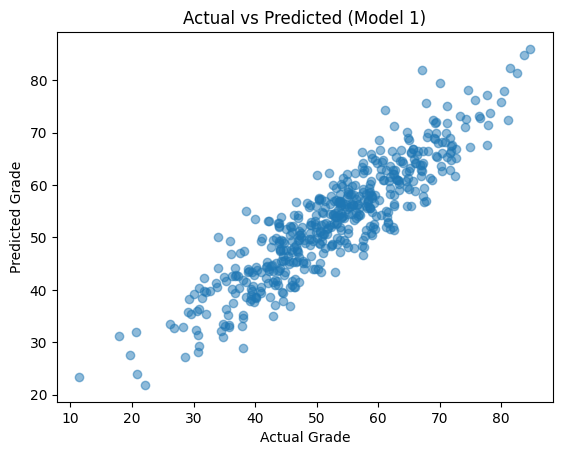

In [ ]:
plt.scatter(y_test[:500], pred1[:500], alpha=0.5)
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Actual vs Predicted (Model 1)')
plt.show()

## 10. Conclusion
Model 1 (ReLU + Adam) performed the best among all configurations:
- ReLU prevents vanishing gradient problems during backpropagation.
- Adam adapts the learning rate per parameter, resulting in faster and smoother convergence.
- Tanh and Sigmoid suffered from slower learning and lower R2 scores compared to ReLU.